In [ ]:
import os
import sys

# 1. Clone the repository (if not already there)
repo_name = "FINRL"
repo_url = "https://github.com/nidarshans/FINRL.git" # Use HTTPS for Colab

if not os.path.exists(repo_name):
    print(f"Cloning {repo_name}...")
    !git clone {repo_url}
else:
    print(f"{repo_name} already exists. Pulling latest changes...")
    %cd {repo_name}
    !git pull
    %cd ..

%cd /content/FINRL/


# 3. Verify imports
try:
    import pandas as pd
    from lib.regime_detection.src.constants import *
    print("✅ Imports successful!")
except ImportError as e:
    print(f"❌ Import failed: {e}")
    print("Current directory contents:", os.listdir())



In [ ]:
# ==============================================================================
# Sector Rotation Regime Detection Model — Modular Sub-package Implementation
# ==============================================================================

import os
import sys
import warnings
warnings.filterwarnings('ignore')


%pip install hmmlearn pandas-ta bt plotly kaleido arch seaborn

try:
    import pandas as pd
    from lib.regime_detection.src.constants import *
    from lib.regime_detection.src.data.loader import download_all, _slice_data
    from lib.regime_detection.src.execution.backtest import train_all_sectors, decode_test_sectors, build_weight_matrix, run_bt_backtest
    from lib.regime_detection.src.execution.walk_forward import run_walk_forward
    from lib.regime_detection.src.utils.plotting import plot_results, print_stats
except ImportError as e:
    print(f"Import failed: {e}")
    print("Current sys.path:", sys.path)
    raise e

def main():
    all_tickers = SECTORS + [BENCHMARK]

    if WALK_FORWARD:
        all_data = download_all(all_tickers, WF_FULL_START, WF_FULL_END)
        (wf_weights, wf_decoded, wf_windows, all_close, bench_series) = run_walk_forward(all_data)
        result, close_prices, weights_aligned = run_bt_backtest(
            wf_weights, all_close, bench_series,
            label=f"HMM Walk-Forward ({WF_MODE})"
        )
        print_stats(result)
        mode_label = f"Walk-Forward {WF_MODE.capitalize()} | train={WF_TRAIN_DAYS}d oos={WF_OOS_DAYS}d"
        plot_results(result, weights_aligned, wf_decoded, close_prices, "sector_rotation_wf.png", wf_windows=wf_windows, mode_label=mode_label)

    else:
        all_data = download_all(all_tickers, TRAIN_START, TEST_END)
        train_data = _slice_data(all_data, TRAIN_START, TRAIN_END)
        test_data = _slice_data(all_data, TEST_START, TEST_END)
        benchmark_test = test_data.pop(BENCHMARK, None)
        if benchmark_test is None: raise RuntimeError("Benchmark SPY missing.")
        
        trained = train_all_sectors(train_data)
        decoded_test = decode_test_sectors(test_data, trained)
        weights = build_weight_matrix(decoded_test)
        close_prices = pd.DataFrame({t: df["Close"] for t, df in test_data.items() if t in weights.columns}).ffill().dropna(how="all")
        bench_series = benchmark_test["Close"].reindex(close_prices.index).ffill()
        
        result, close_prices, weights_aligned = run_bt_backtest(weights, close_prices, bench_series, label="HMM Sector Rotation")
        print_stats(result)
        mode_label = f"Train {TRAIN_START}→{TRAIN_END} | Test {TEST_START}→{TEST_END}"
        plot_results(result, weights_aligned, decoded_test, close_prices, "sector_rotation_results.png", mode_label=mode_label)

    print("\nDone!")
    return result

if __name__ == "__main__":
    result = main()

---
# Correlation Matrix Regime Detection — PCA Diagnostics

**Fully independent section.** Downloads its own data, computes GARCH-adjusted returns
(or KVO % change / raw returns), builds a rolling cross-sector correlation matrix,
and runs PCA to detect regime transitions via eigenvalue spikes.

No dependency on the HMM cells above.

**Note:** Using Matplotlib for reliable rendering in Colab environments.

In [2]:
# ==============================================================================
# PCA Setup — Independent data download & imports
# from IPython.utils import decorators
#============================================================================

import warnings
warnings.filterwarnings('ignore')

#%pip install arch plotly kaleido pandas-ta yfinance seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%cd /Users/nidarshansiddegowda/workspace/FINRL

from lib.regime_detection.src.constants import (
    SECTORS, TRAIN_START, TEST_END, CORR_METRIC, CORR_WINDOW,
)
from lib.regime_detection.src.data.loader import download_all
from lib.regime_detection.src.features.correlation import (
    compute_metric, build_corr_matrix, run_pca_on_corr,
)

SECTORS = [
    'UAL', 'DAL', 'JBLU', 'ALK', 'LUV', 'SKYW'
]
TRAIN_START = "2024-01-01"
TEST_END = "2026-05-14"
# ---- Download data independently ----
pca_data = download_all(SECTORS, TRAIN_START, TEST_END)
print(f"\nLoaded {len(pca_data)} sectors for PCA analysis.")

/Users/nidarshansiddegowda/workspace/FINRL
  Loaded 6/6 tickers from yfinance.

Loaded 6 sectors for PCA analysis.


In [3]:
# ==============================================================================
# Compute Metric → Rolling Correlation Matrix → PCA
# ==============================================================================

# Choose your metric: 'garch_returns' | 'volume' | 'raw_returns'
METRIC = 'volume'   # default from constants, override here if desired
WINDOW = 21   # default 21 trading days

print(f"Metric: {METRIC} | Window: {WINDOW}d")
print("="*60)

metric_df = compute_metric(pca_data, metric=METRIC)
corr_dict = build_corr_matrix(metric_df, window=WINDOW)
eigenvalues_df, pc1_df, explained_df = run_pca_on_corr(
    corr_dict, sectors=list(pca_data.keys())
)

print(f"\nMetric shape: {metric_df.shape}")
print(f"Correlation matrices: {len(corr_dict)}")
print(f"Eigenvalues shape: {eigenvalues_df.shape}")

Metric: volume | Window: 21d
  [CORR] Built 572 rolling correlation matrices (window=21)
  [PCA] Computed eigenvalues for 572 dates, retaining 6 components

Metric shape: (592, 6)
Correlation matrices: 572
Eigenvalues shape: (572, 6)


Plotting Absorption Ratio Evolution...


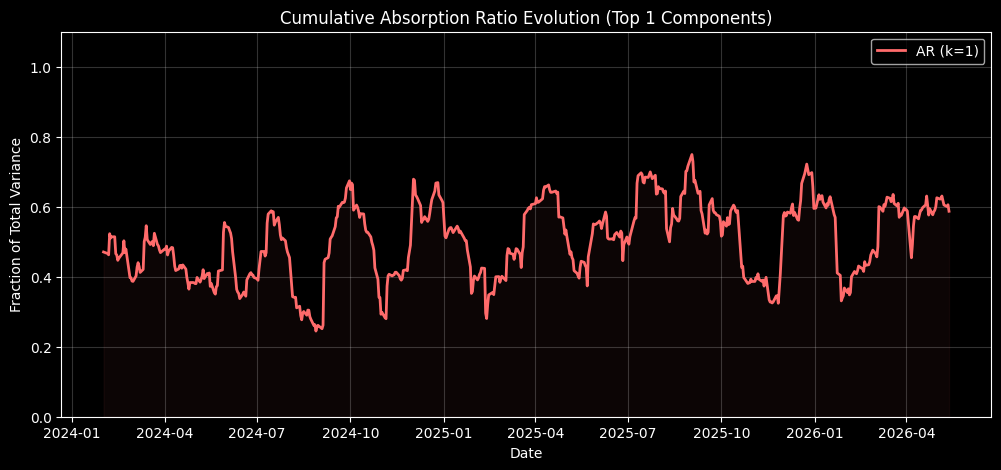

Plotting PC1 Sector Loadings...


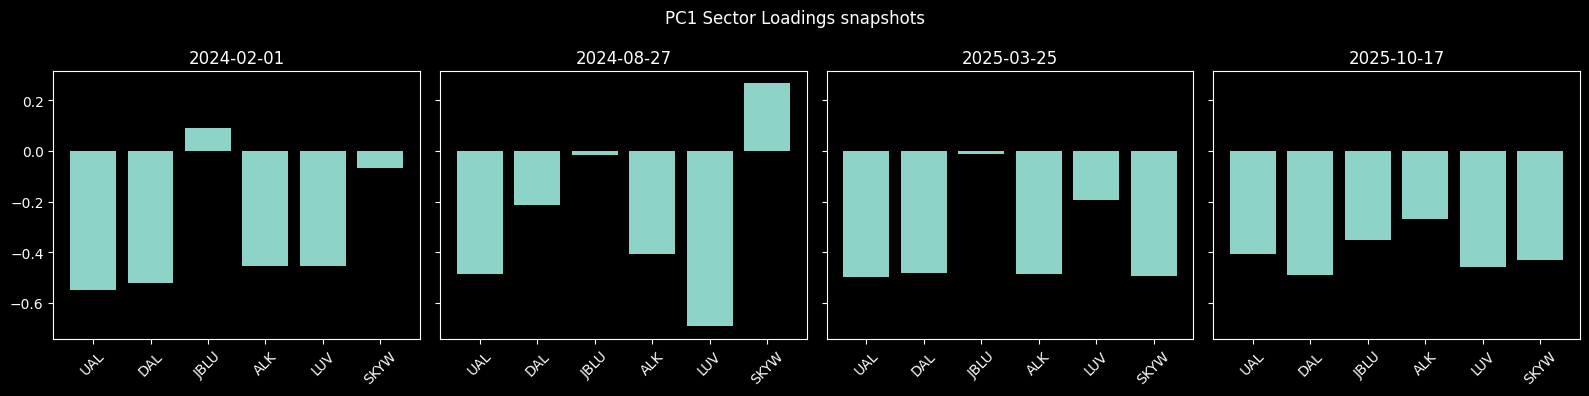

Plotting Correlation Heatmap...


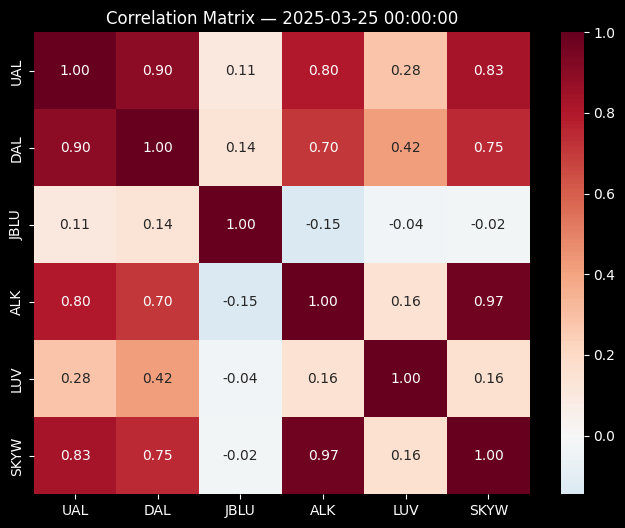

Plotting Regime Overlay...


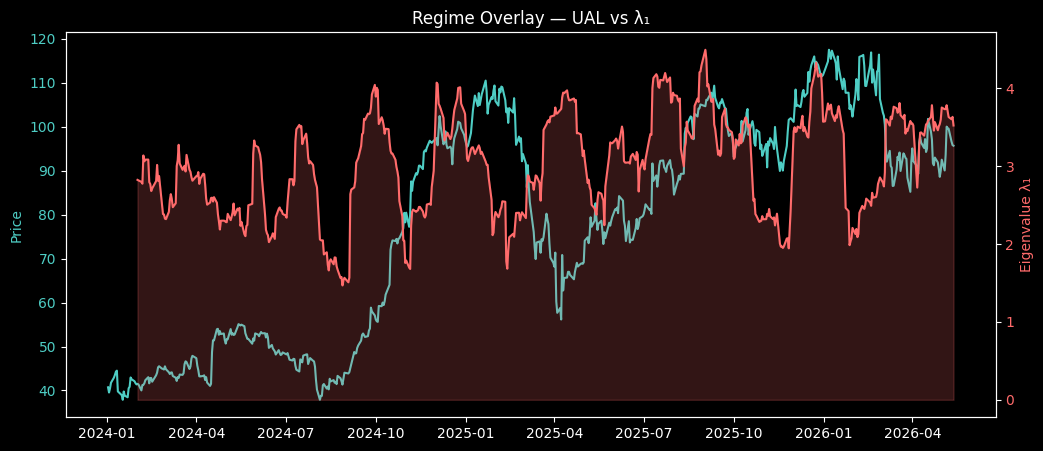

In [4]:
# ==============================================================================
# Visualization (Matplotlib Fallback)
# ==============================================================================
import seaborn as sns
from lib.regime_detection.src.utils.corr_plotting import (
    plot_absorption_ratio_plt, plot_pc1_loadings_plt, plot_corr_heatmap_plt, plot_corr_regime_overlay_plt
)

print("Plotting Absorption Ratio Evolution...")
plot_absorption_ratio_plt(explained_df, k=1)

print("Plotting PC1 Sector Loadings...")
plot_pc1_loadings_plt(pc1_df, sectors=list(pca_data.keys()), n_dates=4)

print("Plotting Correlation Heatmap...")
sorted_dates = sorted(corr_dict.keys())
sample_date = sorted_dates[len(sorted_dates) // 2]
plot_corr_heatmap_plt(corr_dict[sample_date], sample_date, list(pca_data.keys()))

print("Plotting Regime Overlay...")
close_panel = pd.DataFrame({t: pca_data[t]['Close'] for t in pca_data})
target_sector = list(pca_data.keys())[0]
plot_corr_regime_overlay_plt(eigenvalues_df, close_panel, target_sector)
